In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [76]:
df = pd.read_csv('d:/ML/ad_rec.csv')

In [77]:
df.shape

(1000, 10)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  987 non-null    float64
 1   Age                       1000 non-null   int64  
 2   Area Income               987 non-null    float64
 3   Daily Internet Usage      989 non-null    float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      999 non-null    object 
 6   Male                      997 non-null    float64
 7   Country                   991 non-null    object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 78.3+ KB


In [79]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,987.000000,1000.000000,987.000000,989.000000,997.000000,1000.00000
mean,64.929524,36.009000,54980.667234,179.863620,0.480441,0.50000
std,15.844699,8.785562,13439.998510,43.870142,0.499868,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.270000,29.000000,46947.570000,138.710000,0.000000,0.00000
50%,68.110000,35.000000,57009.760000,182.650000,0.000000,0.50000
75%,78.460000,42.000000,65479.350000,218.790000,1.000000,1.00000
max,91.430000,61.000000,79484.800000,267.010000,1.000000,1.00000


In [80]:
df['Ad Topic Line']

0         Cloned 5thgeneration orchestration
1         Monitored national standardization
2           Organic bottom-line service-desk
3      Triple-buffered reciprocal time-frame
4              Robust logistical utilization
                       ...                  
995            Fundamental modular algorithm
996          Grass-roots cohesive monitoring
997             Expanded intangible solution
998     Proactive bandwidth-monitored policy
999          Virtual 5thgeneration emulation
Name: Ad Topic Line, Length: 1000, dtype: object

In [81]:
df['City']

0         Wrightburgh
1           West Jodi
2            Davidton
3      West Terrifurt
4        South Manuel
            ...      
995         Duffystad
996       New Darlene
997     South Jessica
998       West Steven
999       Ronniemouth
Name: City, Length: 1000, dtype: object

In [82]:
df['Male']

0      0.0
1      1.0
2      0.0
3      1.0
4      0.0
      ... 
995    1.0
996    1.0
997    1.0
998    0.0
999    0.0
Name: Male, Length: 1000, dtype: float64

In [83]:
df['Country']

0                     Tunisia
1                       Nauru
2                  San Marino
3                       Italy
4                     Iceland
                ...          
995                   Lebanon
996    Bosnia and Herzegovina
997                  Mongolia
998                 Guatemala
999                    Brazil
Name: Country, Length: 1000, dtype: object

In [84]:
df['Timestamp']

0       3/27/2016 0:53
1        4/4/2016 1:39
2      3/13/2016 20:35
3       1/10/2016 2:31
4        6/3/2016 3:36
            ...       
995    2/11/2016 21:49
996     4/22/2016 2:07
997     2/1/2016 17:24
998     3/24/2016 2:35
999     6/3/2016 21:43
Name: Timestamp, Length: 1000, dtype: object

In [85]:
df['Clicked on Ad']

0      0
1      0
2      0
3      0
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Clicked on Ad, Length: 1000, dtype: int64

In [86]:
df.isna().sum()

Daily Time Spent on Site    13
Age                          0
Area Income                 13
Daily Internet Usage        11
Ad Topic Line                0
City                         1
Male                         3
Country                      9
Timestamp                    0
Clicked on Ad                0
dtype: int64

In [87]:
df.dropna(inplace=True)
df = df.copy()

In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df[df.duplicated()==True]

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad


In [90]:
df = df.drop_duplicates()

In [91]:
df.shape

(953, 10)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Ad Topic Line             953 non-null    object 
 5   City                      953 non-null    object 
 6   Male                      953 non-null    float64
 7   Country                   953 non-null    object 
 8   Timestamp                 953 non-null    object 
 9   Clicked on Ad             953 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 81.9+ KB


In [93]:
df.columns.tolist()

['Daily Time Spent on Site',
 'Age',
 'Area Income',
 'Daily Internet Usage',
 'Ad Topic Line',
 'City',
 'Male',
 'Country',
 'Timestamp',
 'Clicked on Ad']

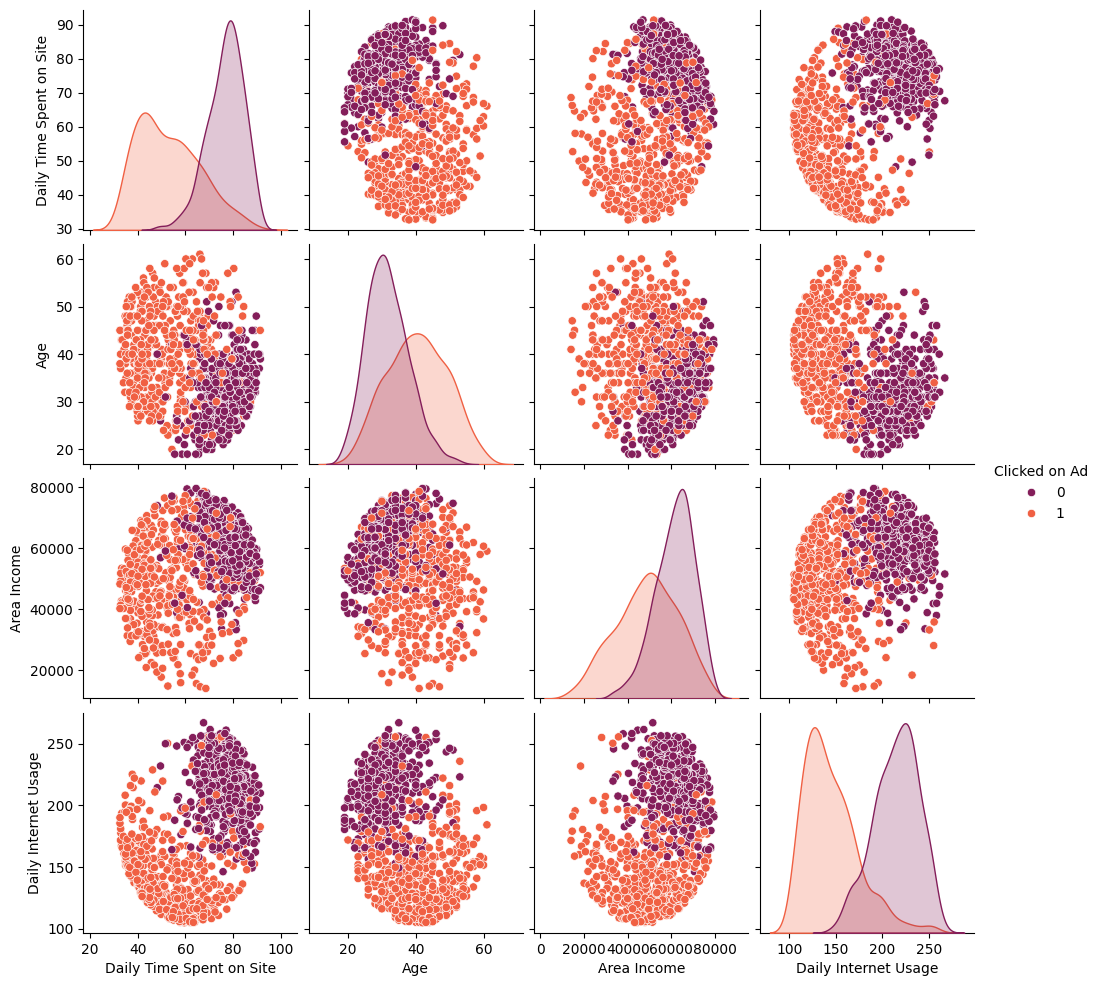

In [94]:
sns.pairplot(df,
             vars=['Daily Time Spent on Site',
                   'Age',
                   'Area Income',
                   'Daily Internet Usage'],
             hue='Clicked on Ad',
             diag_kind='kde',
             palette='rocket')

This pairplot provides a fantastic overview of our numerical variables all at once. By coloring the points based on whether the user clicked the ad, we can already spot some clear separation. For instance, people who spend less time on the site and have lower daily internet usage seem much more likely to click on the ad!

<Axes: xlabel='Age', ylabel='Count'>

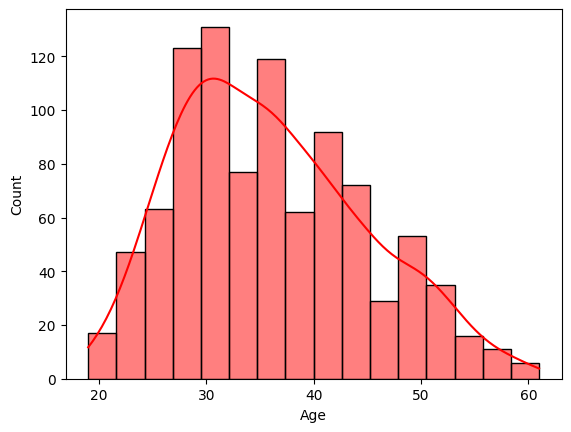

In [95]:
sns.histplot(df['Age'], kde=True, color='r')

Looking specifically at the age distribution, we can see that most users within this dataset are in their late 20s to early 40s. The curve is a bit right-skewed, meaning younger adults are slightly more represented here.

<Axes: xlabel='Age', ylabel='Daily Time Spent on Site'>

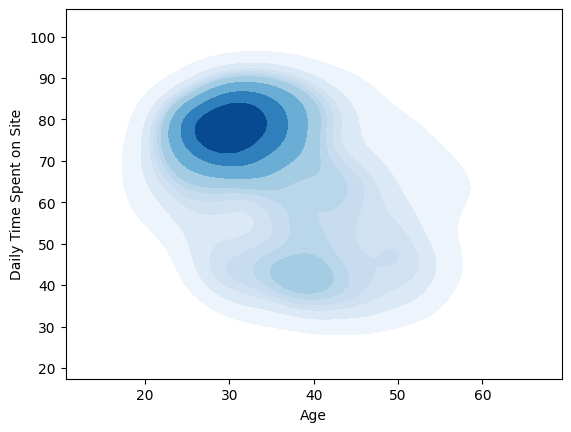

In [96]:
sns.kdeplot(
    x=df['Age'],
    y=df['Daily Time Spent on Site'],
    cmap="Blues",
    fill=True,
    thresh=0.05
)



This 2D density plot looks really cool and gives us a better idea of where our users lie on the spectrum of age and time spent on the site. There's a noticeable hotspot right around 30 years old with an average time spent at around 80 minutes.

<Axes: xlabel='Age', ylabel='count'>

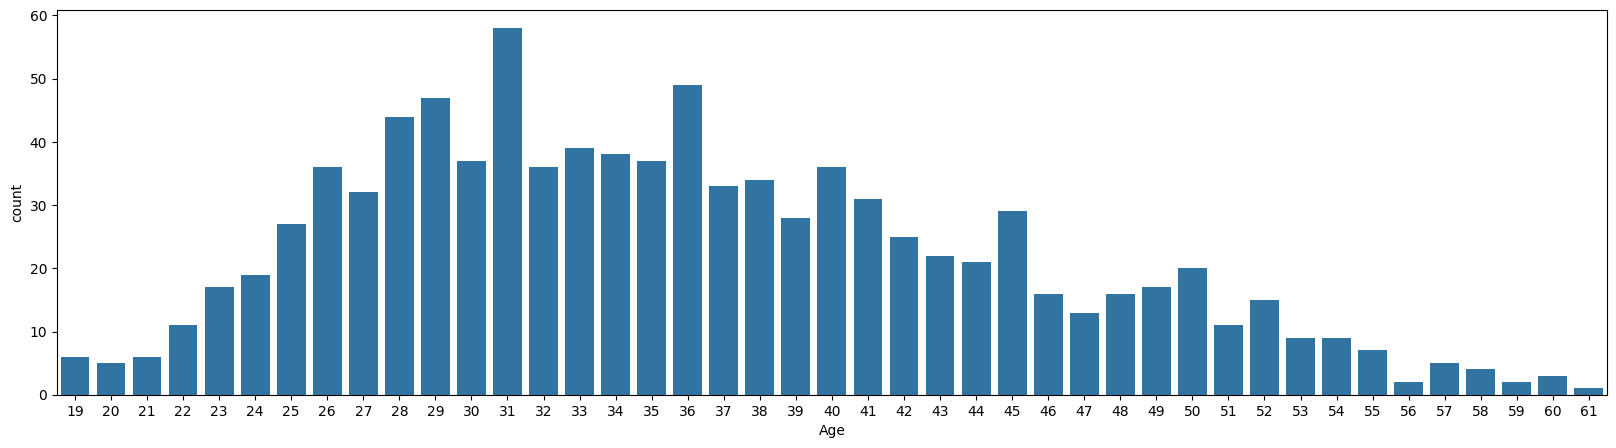

In [97]:
fig = plt.figure(figsize = (20, 5))
sns.countplot(x ='Age', data = df)

By breaking out the age distribution into exact counts, we can pinpoint that 31-year-olds are the most frequent visitors in our dataset, followed closely by 28- and 36-year-olds.

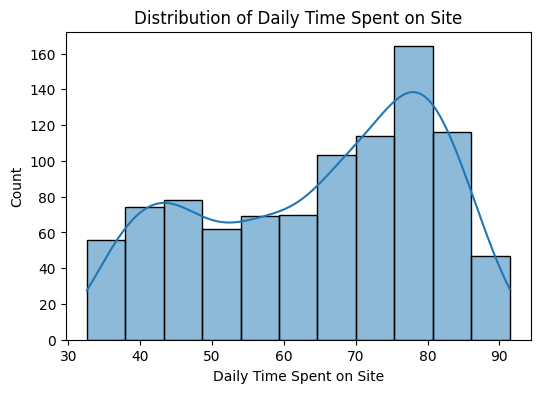

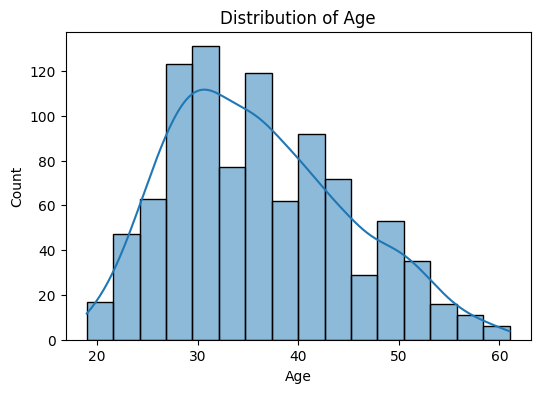

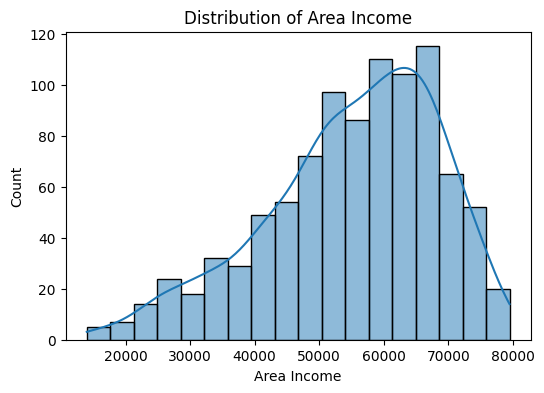

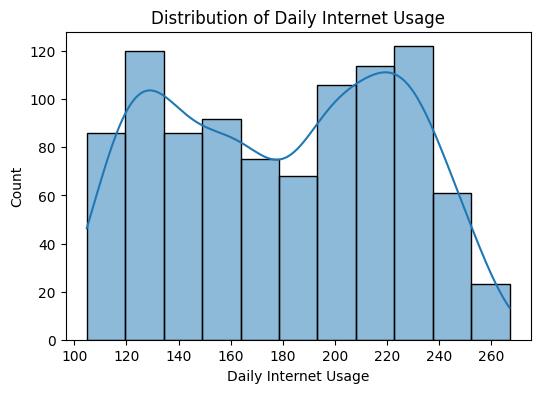

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Here we check the distribution for each key numeric feature. We see that 'Area Income' is left-skewed, showing higher typical earnings, and interestingly, 'Daily Internet Usage' is bimodal, meaning we might have two distinct groups of users: high usage and lower usage.

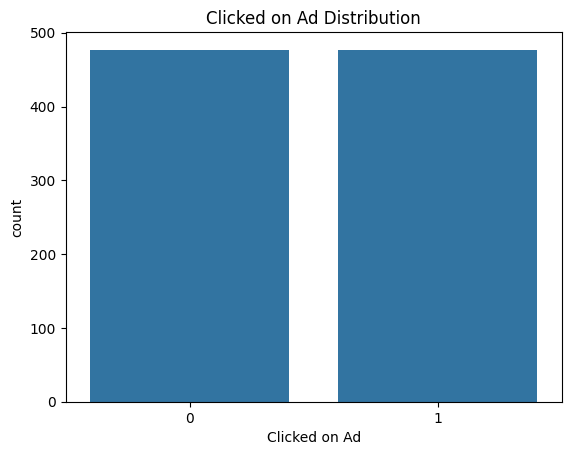

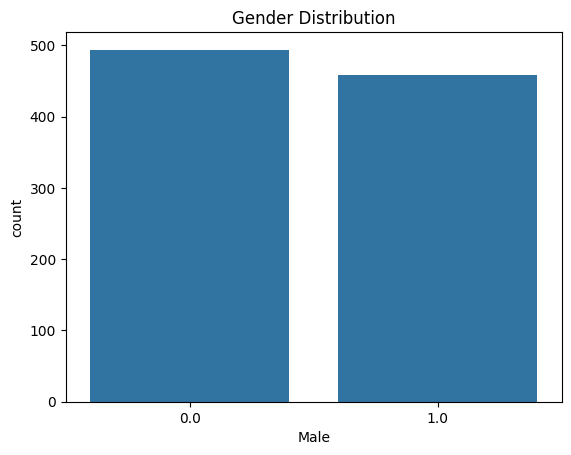

In [99]:
sns.countplot(x='Clicked on Ad', data=df)
plt.title('Clicked on Ad Distribution')
plt.show()

sns.countplot(x='Male', data=df)
plt.title('Gender Distribution')
plt.show()

Checking the class balance is a super important step. We're in luck! The dataset is perfectly balanced in terms of our target variable `Clicked on Ad` (a nice 50/50 split), and the gender distribution is almost completely equal as well. This makes our modeling so much easier later!

<Axes: xlabel='Age', ylabel='Daily Time Spent on Site'>

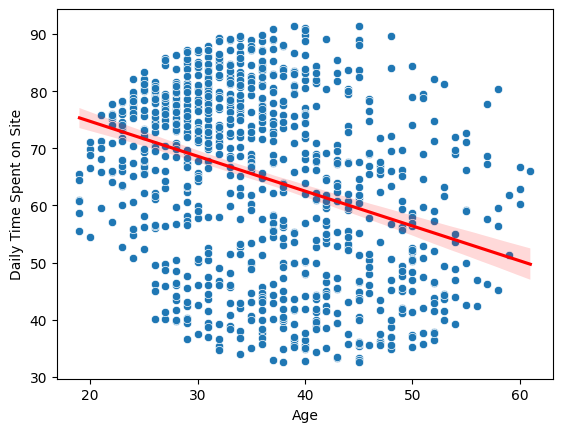

In [100]:
sns.scatterplot(x='Age', y='Daily Time Spent on Site', data=df)
sns.regplot(x='Age', y='Daily Time Spent on Site', data=df,
            scatter=False, color='red')

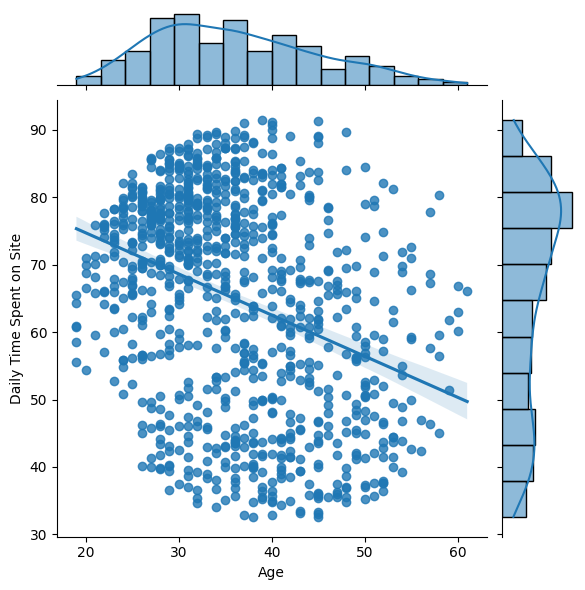

In [101]:
sns.jointplot(
    x='Age',
    y='Daily Time Spent on Site',
    data=df ,
    kind='reg'
)

Looking closer at the relationship between Age and Daily Time Spent on Site, these scatter and joint plots reveal a slight negative correlation. As users get older, they tend to spend slightly less time on the site on average. The marginal histograms also nicely show the concentration of our users' ages and their site duration.

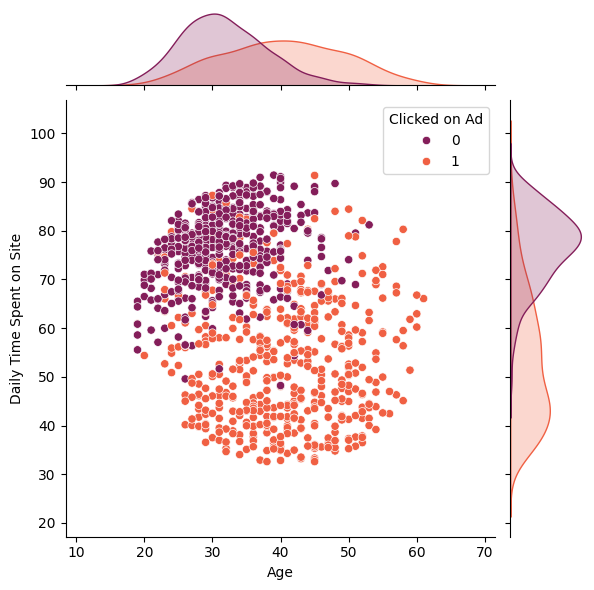

In [102]:
sns.jointplot(x='Age',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')

This jointplot perfectly contrasts how age and time spent on the site interact regarding ad clicks. It’s pretty apparent: older users and those who spend less time on the site are the ones clicking the ad more often!

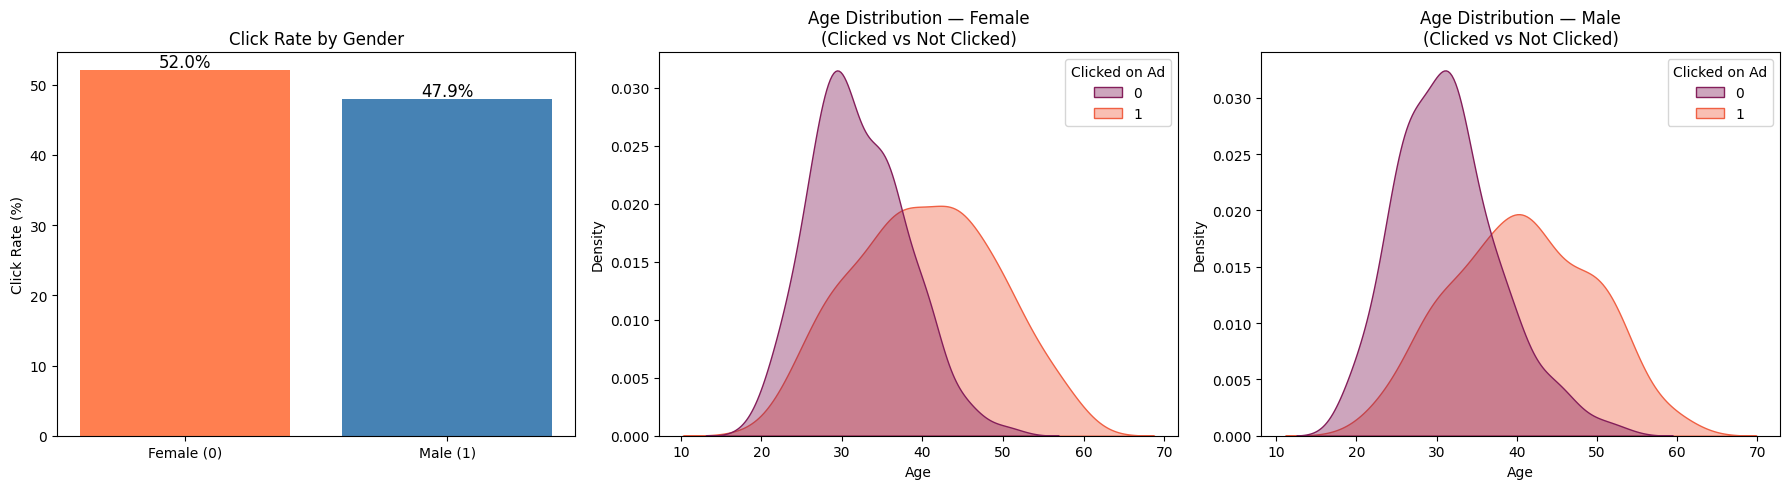


Click counts by gender:
Clicked on Ad    0    1
Male                   
0.0            237  257
1.0            239  220


C:\Users\hp5cd\AppData\Local\Temp\ipykernel_21100\1672608944.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Female', 'Male'])
C:\Users\hp5cd\AppData\Local\Temp\ipykernel_21100\1672608944.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female', 'Male'])


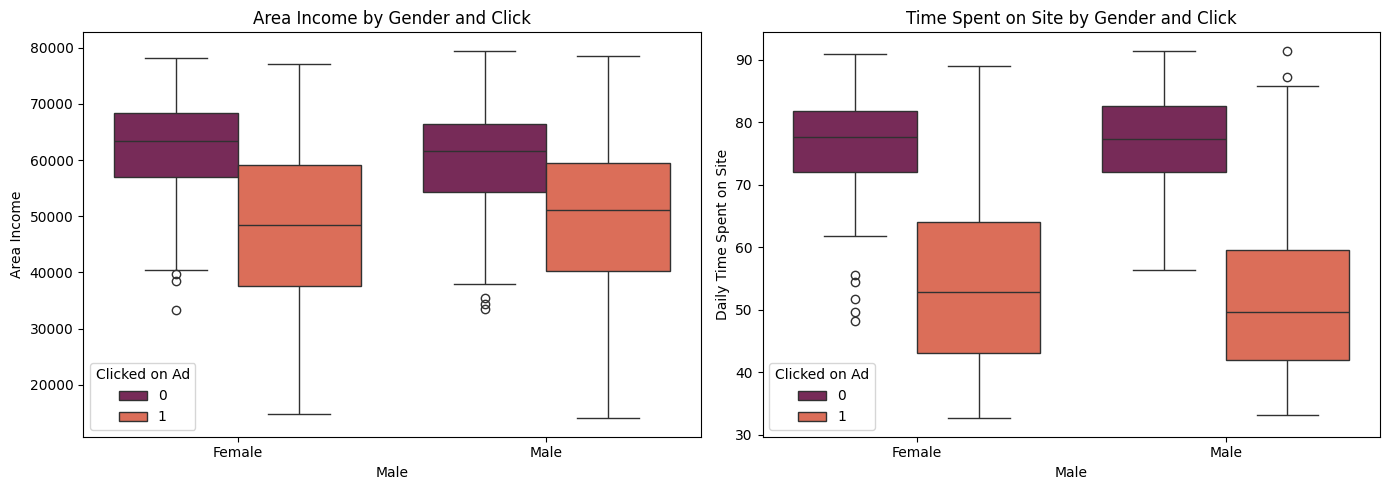

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Click rate by gender
gender_click = df.groupby('Male')['Clicked on Ad'].mean() * 100
axes[0].bar(['Female (0)', 'Male (1)'], gender_click.values, color=['coral', 'steelblue'])
axes[0].set_title('Click Rate by Gender')
axes[0].set_ylabel('Click Rate (%)')
for i, v in enumerate(gender_click.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# 2. Age distribution by gender (hue=click)
sns.kdeplot(data=df[df['Male'] == 0], x='Age', hue='Clicked on Ad',
            ax=axes[1], palette='rocket', fill=True, alpha=0.4)
axes[1].set_title('Age Distribution — Female\n(Clicked vs Not Clicked)')
axes[1].set_xlabel('Age')

sns.kdeplot(data=df[df['Male'] == 1], x='Age', hue='Clicked on Ad',
            ax=axes[2], palette='rocket', fill=True, alpha=0.4)
axes[2].set_title('Age Distribution — Male\n(Clicked vs Not Clicked)')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

# 3. Count of clicks by gender
print("\nClick counts by gender:")
print(df.groupby(['Male', 'Clicked on Ad']).size().unstack())

# 4. Internet usage & time spent by gender and click
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Male', y='Area Income', hue='Clicked on Ad',
            data=df, ax=axes[0], palette='rocket')
axes[0].set_title('Area Income by Gender and Click')
axes[0].set_xticklabels(['Female', 'Male'])

sns.boxplot(x='Male', y='Daily Time Spent on Site', hue='Clicked on Ad',
            data=df, ax=axes[1], palette='rocket')
axes[1].set_title('Time Spent on Site by Gender and Click')
axes[1].set_xticklabels(['Female', 'Male'])

plt.tight_layout()
plt.show()

Breaking down the data by gender reveals some interesting insights. However, the click rates are fairly similar across both male and female groups (~50%). Also, the age distributions when segmented by clicks look similar between genders. It seems gender isn't as huge of a differentiating factor for clicking ads compared to age or time spent on the site!

<Axes: xlabel='Daily Time Spent on Site', ylabel='Area Income'>

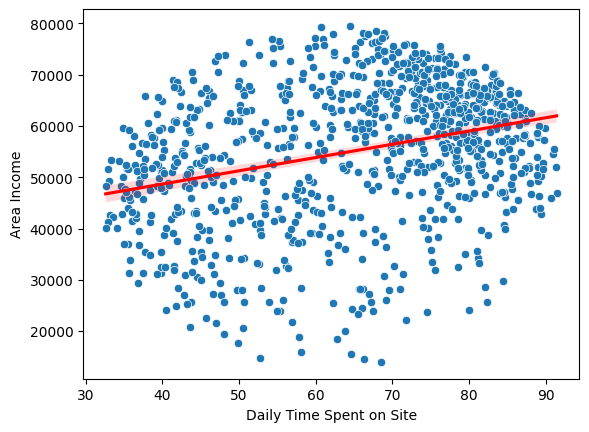

In [104]:
sns.scatterplot(x='Daily Time Spent on Site', y='Area Income', data=df)
sns.regplot(x='Daily Time Spent on Site', y='Area Income', data=df,
            scatter=False, color='red')

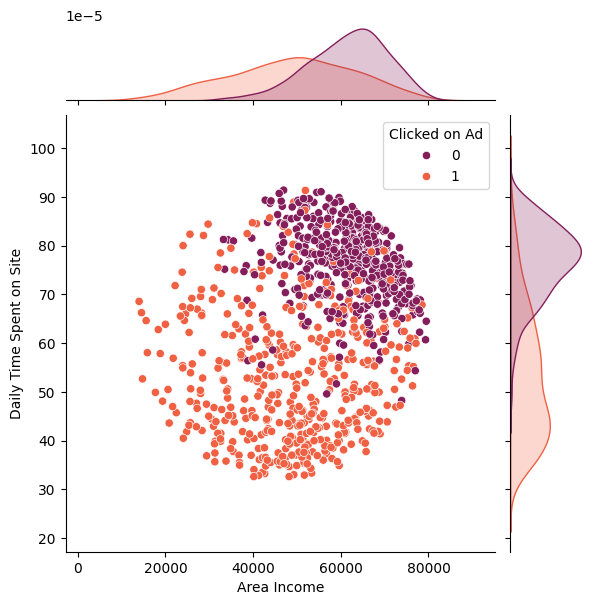

In [105]:
sns.jointplot(x='Area Income',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')

Here we're comparing Area Income with Daily Time Spent on Site. The regression line suggests a positive relationship: users from higher-income areas generally spend more time on the site. When we color by whether they clicked the ad, we can clearly see that the ad-clickers completely dominate the lower-income and lower-time-spent region of the graph!

<Axes: xlabel='Daily Internet Usage', ylabel='Age'>

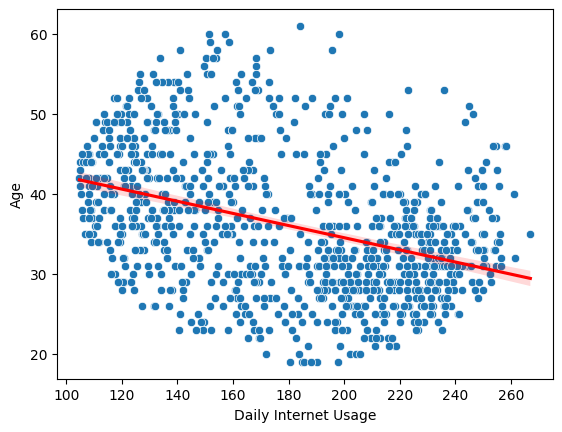

In [106]:
sns.scatterplot(x='Daily Internet Usage', y='Age', data=df)
sns.regplot(x='Daily Internet Usage', y='Age', data=df,
            scatter=False, color='red')

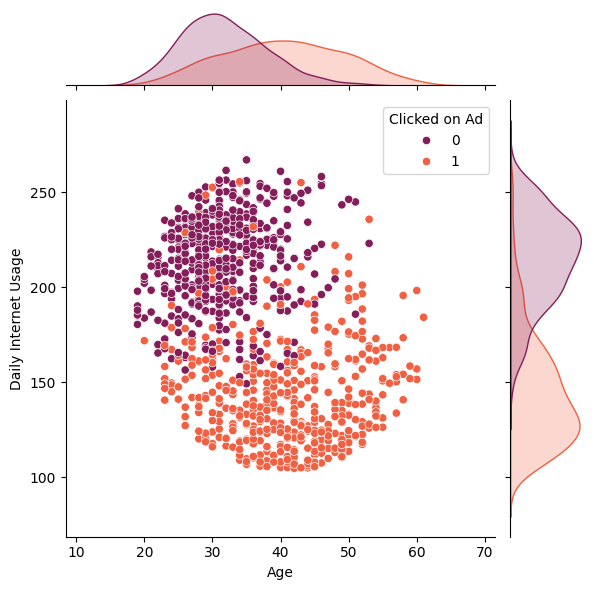

In [107]:
sns.jointplot(x='Age',y='Daily Internet Usage', data=df, hue="Clicked on Ad", palette='rocket')

Let's see how Age relates to Daily Internet Usage. Much like their time spent on the site, older users tend to use the internet less overall. Splitting this by clicks, we find our audience that clicked the ad is heavily concentrated in the older demographic with lower daily internet usage.

<Axes: xlabel='Daily Time Spent on Site', ylabel='Daily Internet Usage'>

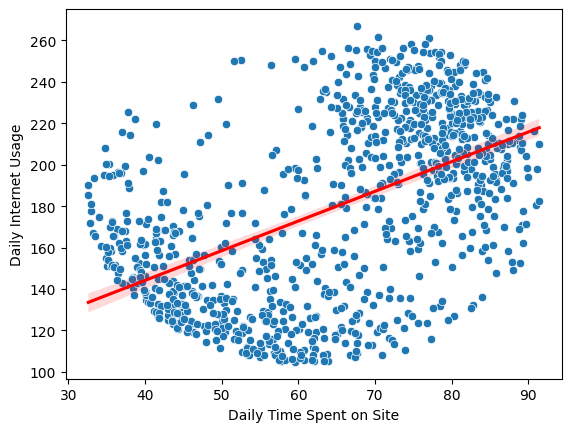

In [108]:
sns.scatterplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=df)
sns.regplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=df,
            scatter=False, color='red')

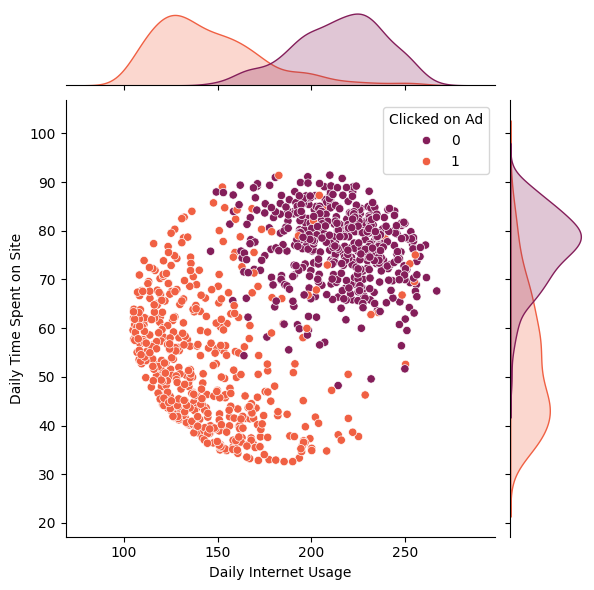

In [109]:
sns.jointplot(x='Daily Internet Usage',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')


Finally, comparing Daily Internet Usage against Daily Time Spent on Site gives us one of the clearest dividing lines in our entire dataset. The two variables track positively together, but more importantly, the jointplot almost perfectly segregates our users: high internet/high site time users usually don't click, while low internet/low site time users are very likely to click!

<Axes: >

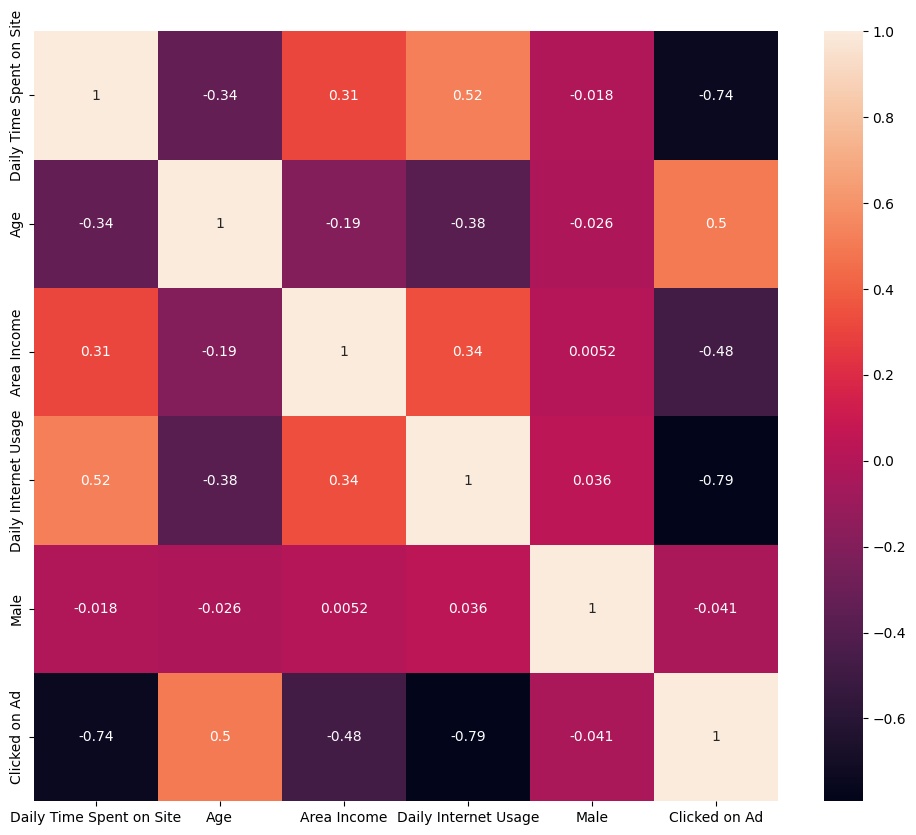

In [110]:
fig = plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only = True), annot=True)

This correlation heatmap is super useful for spotting relationships between our numerical variables. We can clearly see a strong negative correlation between `Clicked on Ad` and both `Daily Time Spent on Site` & `Daily Internet Usage`. Basically, the less time people spend online and on the site, the more likely they are to click!

In [111]:
df['Ad Topic Line'].describe(include=['O'])

count                                 953
unique                                953
top       Virtual 5thgeneration emulation
freq                                    1
Name: Ad Topic Line, dtype: object

In [112]:
df['City'].describe(include=['O'])

count              953
unique             926
top       Williamsport
freq                 3
Name: City, dtype: object

In [113]:
df['Country'].describe(include=['O'])

count                953
unique               235
top       Czech Republic
freq                   9
Name: Country, dtype: object

In [114]:
df = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male','Timestamp', 'Clicked on Ad']].copy()

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Male                      953 non-null    float64
 5   Timestamp                 953 non-null    object 
 6   Clicked on Ad             953 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 59.6+ KB


In [116]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [117]:
df["Month"] = df['Timestamp'].dt.month

In [118]:
df['Day'] = df['Timestamp'].dt.day

In [119]:
df['Weekday'] = df['Timestamp'].dt.dayofweek

In [120]:
df['Hour'] = df['Timestamp'].dt.hour

In [121]:
df['DayOfWeek'] = df['Timestamp'].dt.day_name()


In [122]:
df = df.drop(['Timestamp'], axis=1)

In [123]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Month,Day,Weekday,Hour,DayOfWeek
0,68.95,35,61833.90,256.09,0.0,0,3,27,6,0,Sunday
1,80.23,31,68441.85,193.77,1.0,0,4,4,0,1,Monday
2,69.47,26,59785.94,236.50,0.0,0,3,13,6,20,Sunday
3,74.15,29,54806.18,245.89,1.0,0,1,10,6,2,Sunday
4,68.37,35,73889.99,225.58,0.0,0,6,3,4,3,Friday


In [124]:
df['Month'].unique()

array([3, 4, 1, 6, 5, 7, 2], dtype=int32)

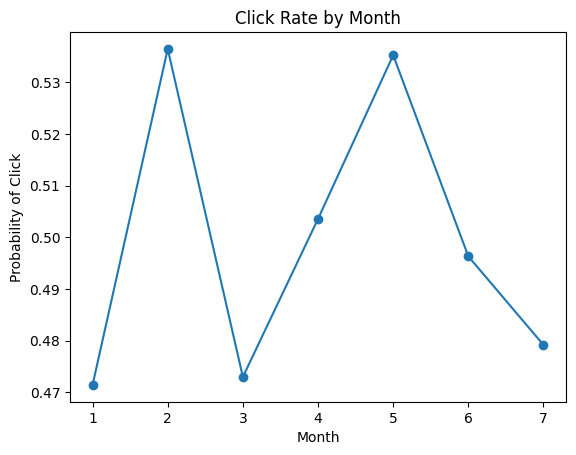

In [125]:
hour_click_rate = df.groupby('Month')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Month")
plt.ylabel("Probability of Click")
plt.show()

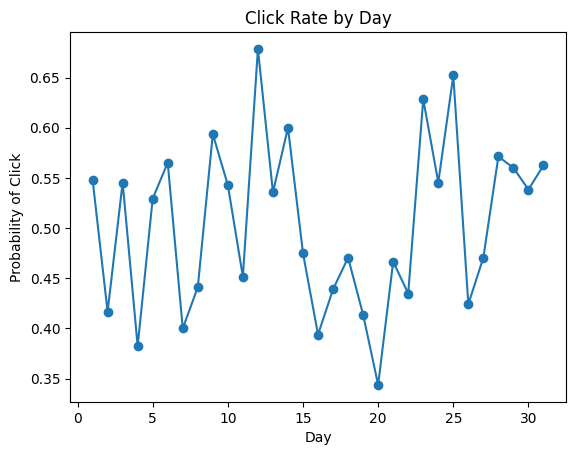

In [126]:
hour_click_rate = df.groupby('Day')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Day")
plt.ylabel("Probability of Click")
plt.show()

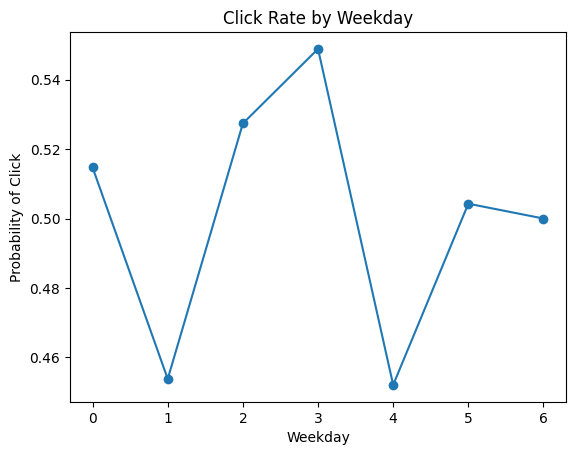

In [127]:
hour_click_rate = df.groupby('Weekday')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Weekday")
plt.ylabel("Probability of Click")
plt.show()

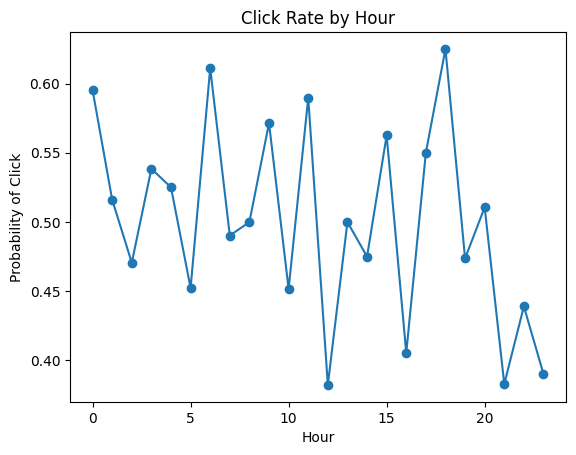

In [128]:
hour_click_rate = df.groupby('Hour')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Hour")
plt.ylabel("Probability of Click")
plt.show()

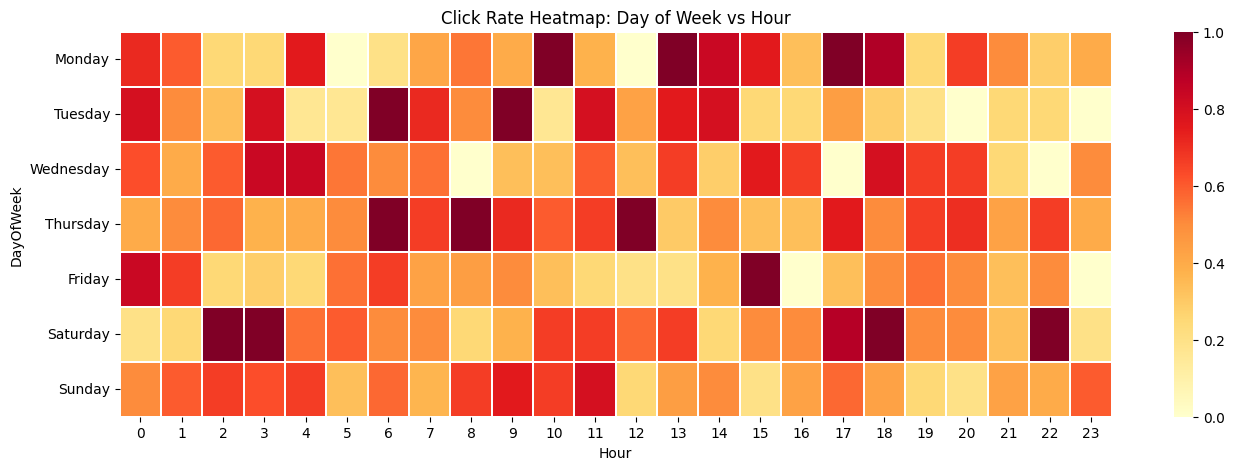

In [129]:


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = df.pivot_table(values='Clicked on Ad', index='DayOfWeek', columns='Hour', aggfunc='mean')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.3)
plt.title('Click Rate Heatmap: Day of Week vs Hour')
plt.show()

This heatmap beautifully summarizes the temporal patterns! By looking at the day of the week versus the hour of the day, we can pinpoint precisely when users are most likely to click on ads. Some specific hours on certain days have noticeably much higher click rates. This could be invaluable for timing our future ad campaigns!

<Axes: xlabel='Hour', ylabel='Daily Time Spent on Site'>

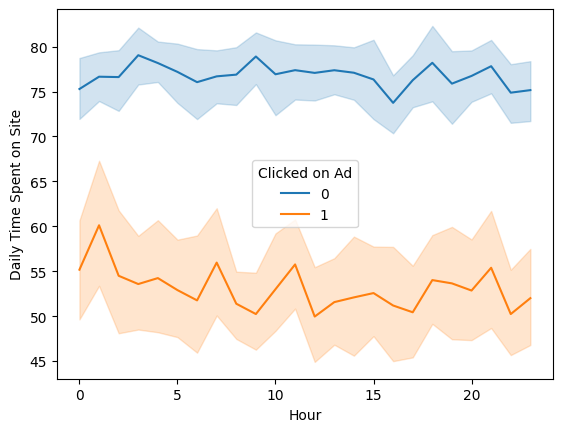

In [130]:
sns.lineplot(x='Hour', y='Daily Time Spent on Site', hue='Clicked on Ad', data=df)

This line plot shows how the average 'Daily Time Spent on Site' varies across different hours of the day, split by whether they clicked the ad or not. The huge gap between the two lines perfectly illustrates our earlier finding: users who spend less time on the site are consistently more likely to click the ad, regardless of the hour!

<Axes: xlabel='Daily Time Spent on Site', ylabel='Count'>

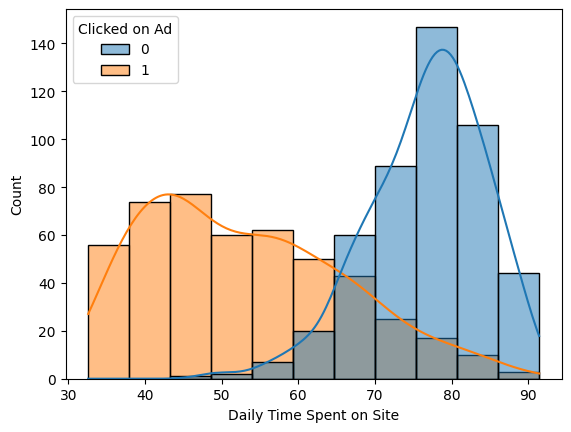

In [131]:
sns.histplot(data=df, x='Daily Time Spent on Site', hue='Clicked on Ad', kde=True)

This distribution strictly compares the time spent on the site between those who clicked and those who didn't. The overlapping histograms show a stark contrast: users who click on the ad tend to spend significantly less time on the site (peaking around 40-50 minutes) compared to users who ignore the ad (peaking around 80 minutes).

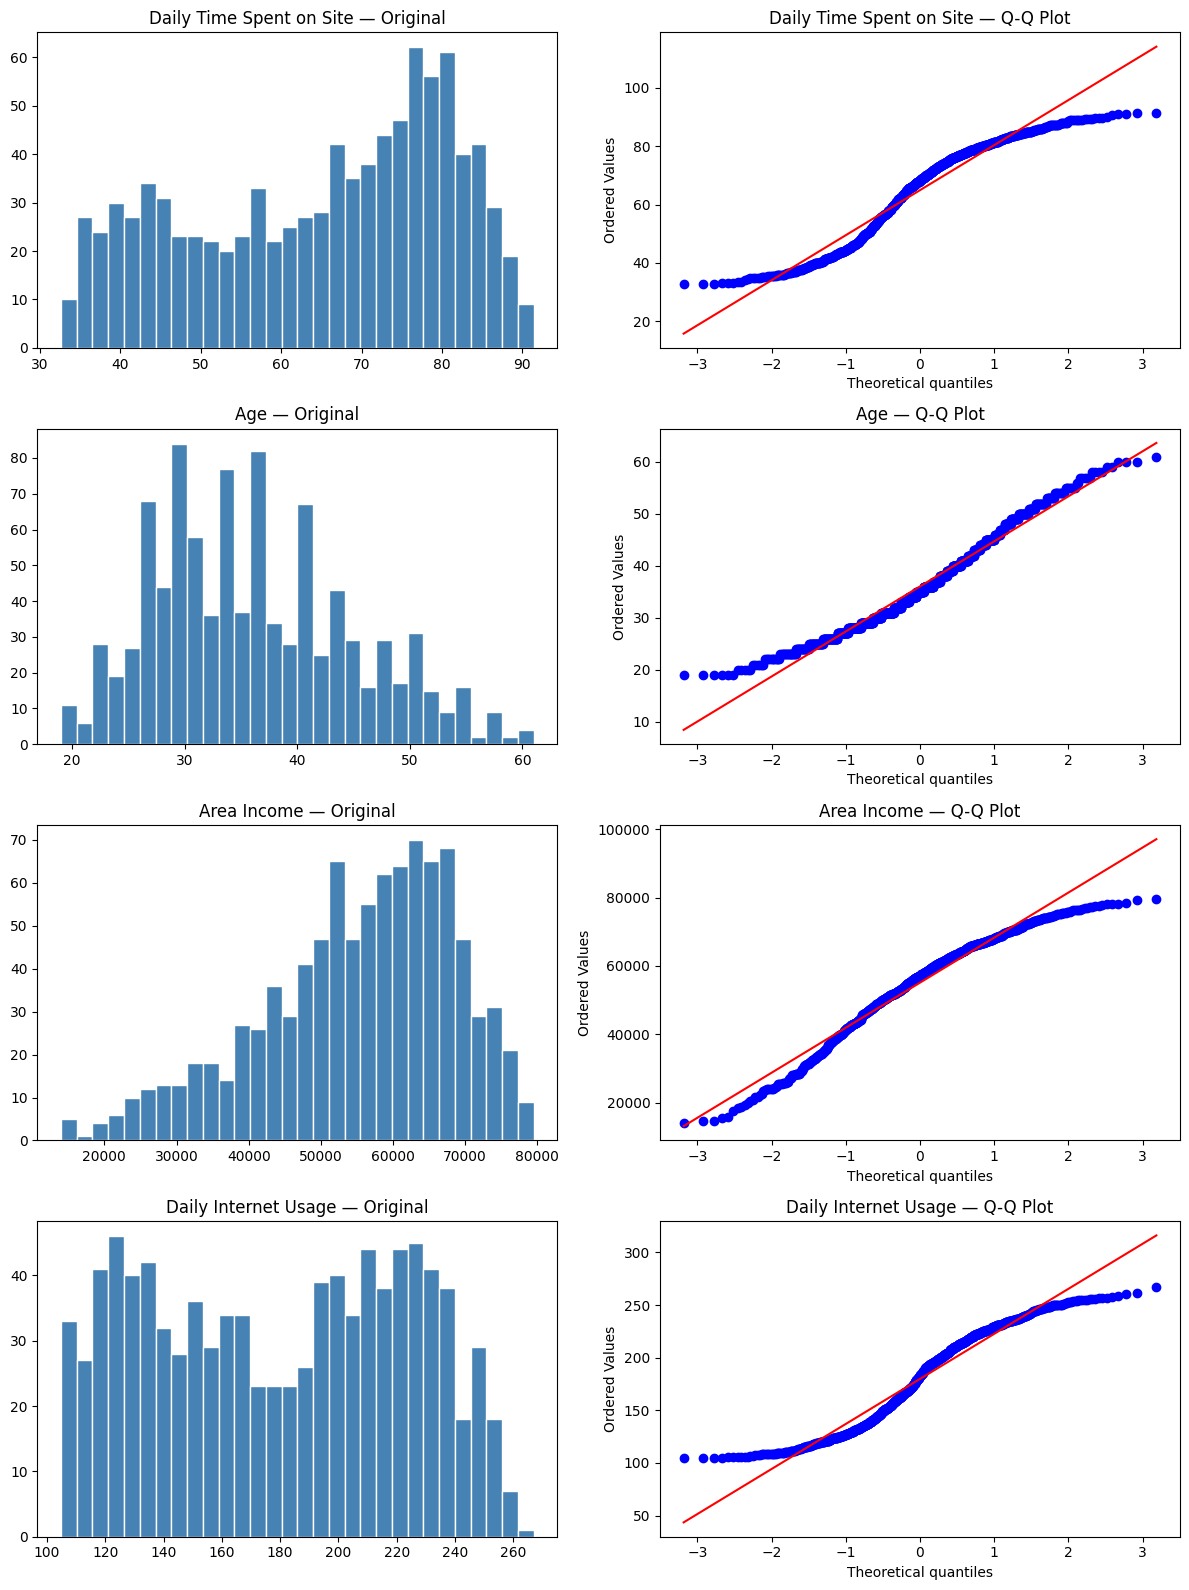

Skewness:
Daily Time Spent on Site   -0.376507
Age                         0.468162
Area Income                -0.654497
Daily Internet Usage       -0.035391
dtype: float64


In [132]:
import scipy.stats as stats

num_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 16))

for i, col in enumerate(num_cols):
    # Original distribution
    axes[i, 0].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Original')
    
    # Q-Q plot to check normality
    stats.probplot(df[col], plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — Q-Q Plot')

plt.tight_layout()
plt.show()

# Skewness values
print("Skewness:")
print(df[num_cols].skew())

To get a deeper look at the distribution shape, we also plot Quantile-Quantile (Q-Q) plots and calculate skewness. This helps us see how closely our numeric features resemble a normal distribution, which is a great thing to know before deciding on scaling or transformation techniques for our machine learning models later. So on looking at the values we can see that the values lie between -0.5 to 0.5 so donot require any transformation.Apart from Area Income but it is negligible we can procedd to modal training without applying log transformations. 

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Male                      953 non-null    float64
 5   Clicked on Ad             953 non-null    int64  
 6   Month                     953 non-null    int32  
 7   Day                       953 non-null    int32  
 8   Weekday                   953 non-null    int32  
 9   Hour                      953 non-null    int32  
 10  DayOfWeek                 953 non-null    object 
dtypes: float64(4), int32(4), int64(2), object(1)
memory usage: 74.5+ KB


In [135]:
x = df.drop(columns=['Clicked on Ad','DayOfWeek'], axis=1)

In [136]:
x.shape

(953, 9)

In [137]:
y = df['Clicked on Ad']

In [138]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [139]:
X_train.shape

(667, 9)

In [140]:
y_train.shape

(667,)

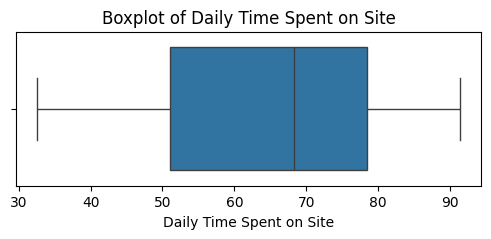

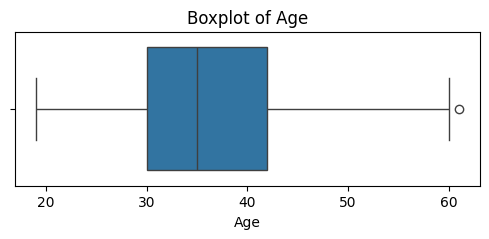

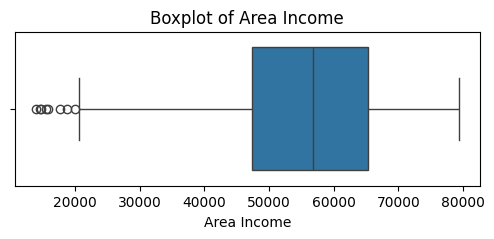

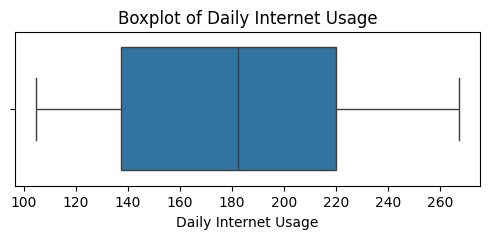

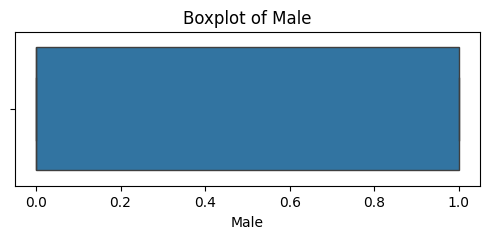

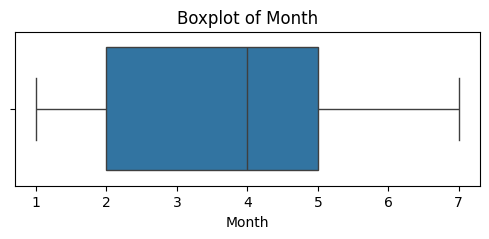

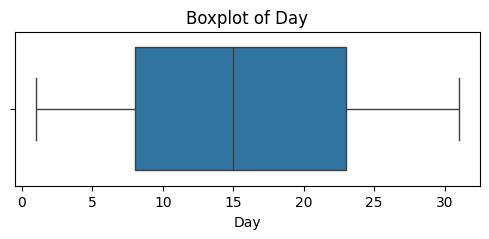

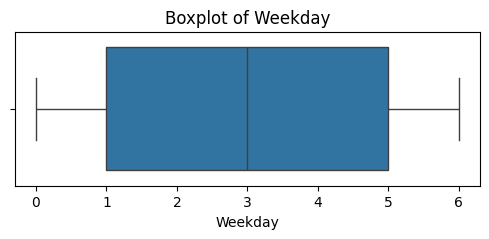

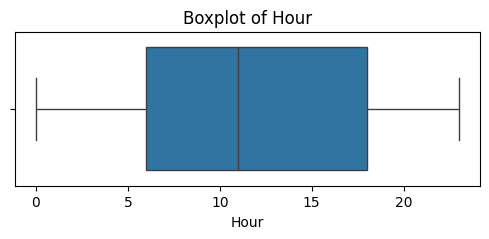

In [141]:
for col in X_train.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Finally, before training our models, let's plot boxplots for all of our features in the training set. This is a vital step because it quickly visualizes the median, quartiles, and highlights any potential outliers that we might need to handle or remove before feeding this data into our algorithms.

In [142]:
def remove_outliers_iqr(df, columns, multiplier=1.5):
    """
    Remove rows where any specified column has a value
    outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR].
    
    multiplier=1.5 → standard outliers
    multiplier=3.0 → only extreme outliers
    """
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        print(f"[IQR] {col}: removed {before - len(df_clean)} rows | "
              f"bounds [{lower:.2f}, {upper:.2f}]")
    return df_clean

In [143]:
X_train_clean = remove_outliers_iqr(X_train, columns=[ 'Area Income'], multiplier=1.5)
y_train = y_train.loc[X_train_clean.index]

[IQR] Area Income: removed 8 rows | bounds [20448.79, 92251.14]


In [144]:
scaler = StandardScaler()

In [145]:
X_train = scaler.fit_transform(X_train_clean)

In [146]:
X_test = scaler.transform(X_test)

In [147]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [148]:
cnf_matrix = confusion_matrix(y_test,y_pred)
print(cnf_matrix)

[[141   7]
 [  2 136]]


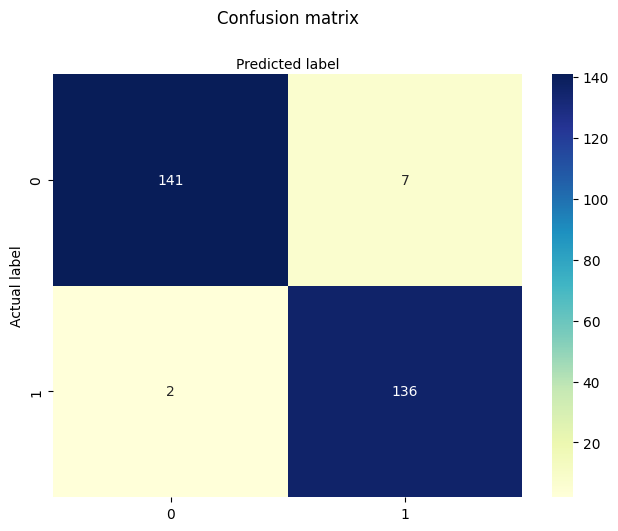

In [149]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [150]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       148
           1       0.95      0.99      0.97       138

    accuracy                           0.97       286
   macro avg       0.97      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



In [151]:
test_pred = lr.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

In [152]:
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9685


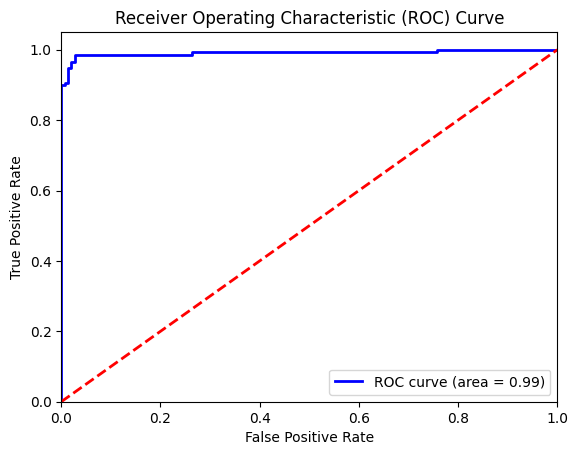

In [153]:
from sklearn.metrics import roc_curve, auc
y_prob = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [154]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=6,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [155]:
cnf_matrix = confusion_matrix(y_test,y_pred)
print(cnf_matrix)

[[138  10]
 [  6 132]]


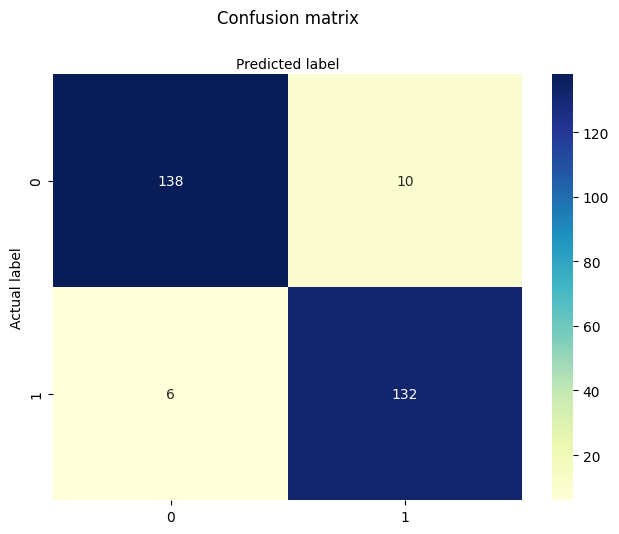

In [156]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [157]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       148
           1       0.93      0.96      0.94       138

    accuracy                           0.94       286
   macro avg       0.94      0.94      0.94       286
weighted avg       0.94      0.94      0.94       286



In [158]:
test_acc = model.predict(X_test)
test_acc = accuracy_score(y_test, test_acc)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9441


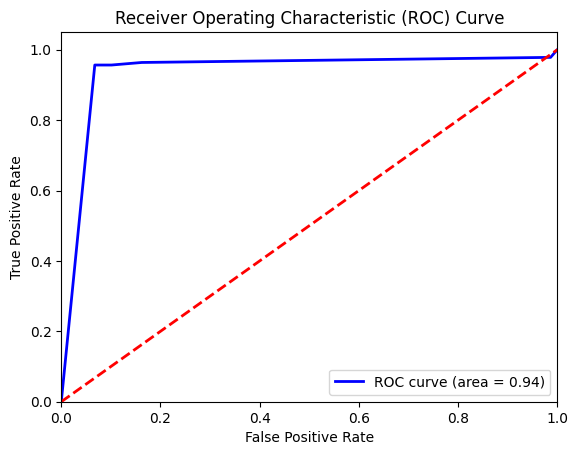

In [159]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [160]:
feature_names = ['Daily Time Spent on Site', 'Age', 'Area Income',
                 'Daily Internet Usage', 'Male','Month','Day','Weekday','Hour']

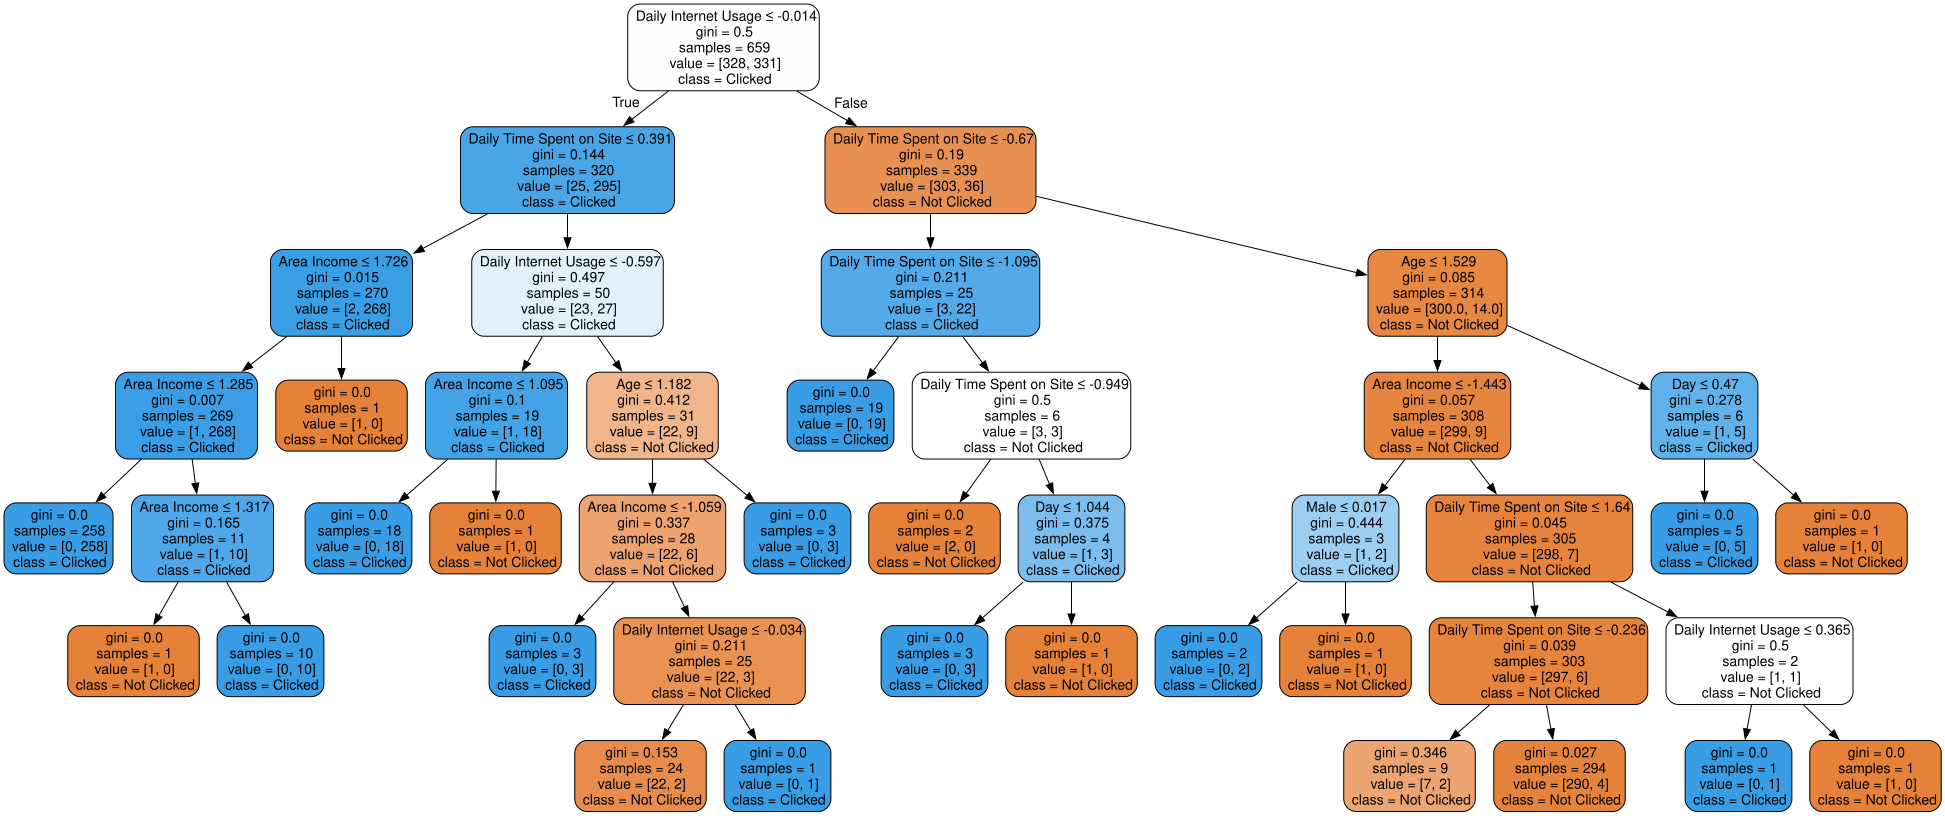

In [161]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=feature_names,
    class_names=['Not Clicked', 'Clicked'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

In [162]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#SVM model 
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)


svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [163]:
cnf_matrix = confusion_matrix(y_test,y_pred_svm)
print(cnf_matrix)

[[143   5]
 [  4 134]]


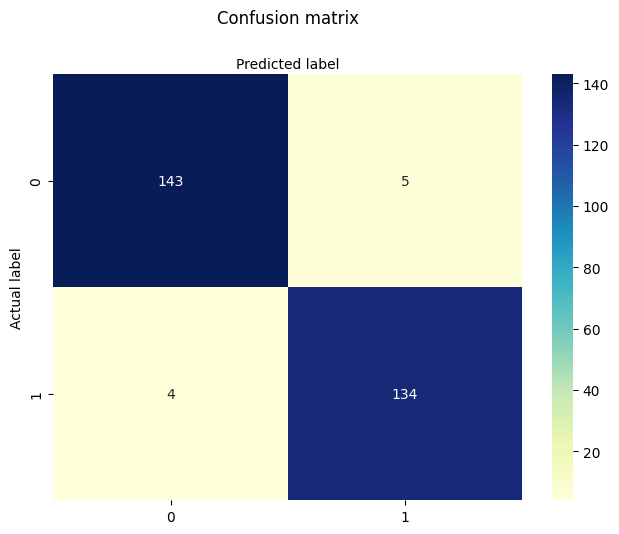

In [164]:
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [165]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       148
           1       0.96      0.97      0.97       138

    accuracy                           0.97       286
   macro avg       0.97      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



In [166]:
test_pred = svm_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9685


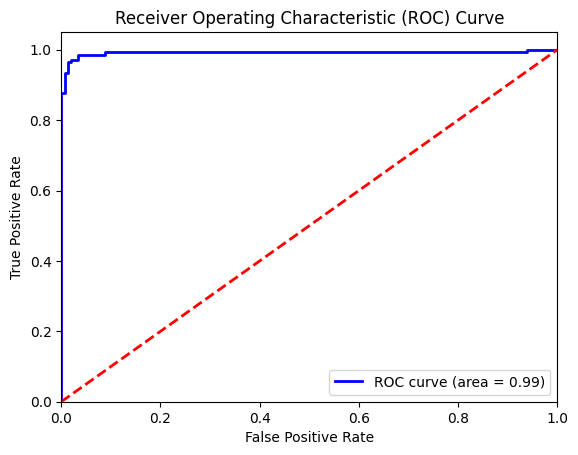

In [167]:
y_prob = svm_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [168]:
from sklearn.tree import plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [169]:
base = DecisionTreeClassifier(max_depth=1)

clf = AdaBoostClassifier(
    estimator=base,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

In [170]:
clf.fit(X_train, y_train)
y_pred_ada = clf.predict(X_test)


In [171]:
conf_matrix = confusion_matrix(y_test,y_pred_ada)
print(conf_matrix)

[[141   7]
 [  4 134]]


In [172]:
classification_report(y_test, y_pred_ada)
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       148
           1       0.95      0.97      0.96       138

    accuracy                           0.96       286
   macro avg       0.96      0.96      0.96       286
weighted avg       0.96      0.96      0.96       286



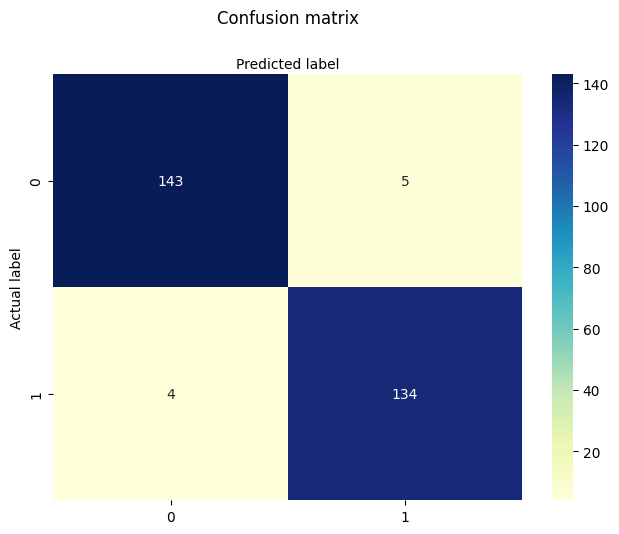

In [173]:
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [174]:
test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)    
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9615


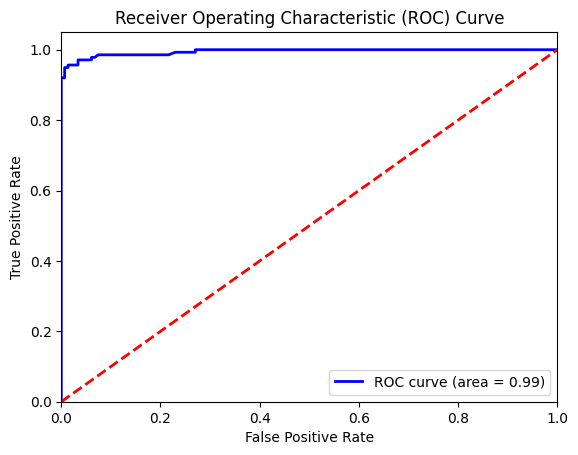

In [175]:
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

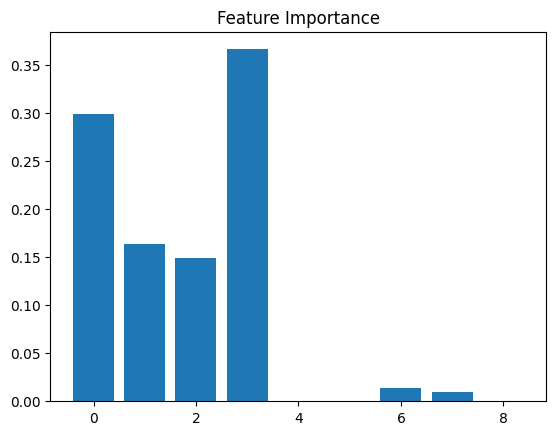

In [176]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

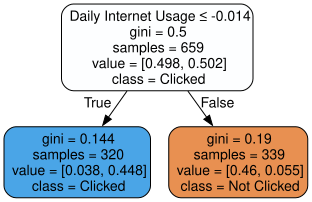

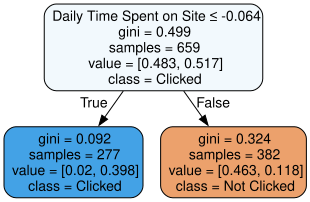

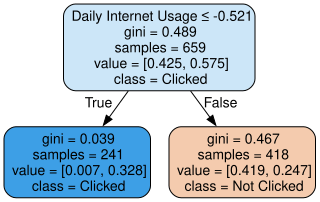

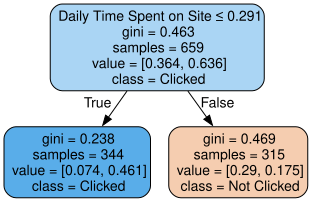

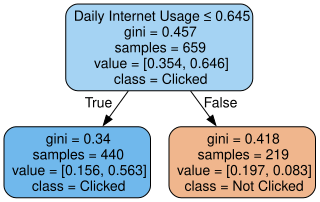

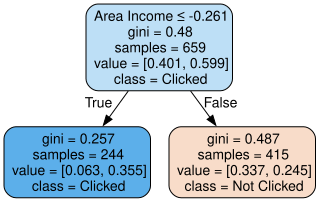

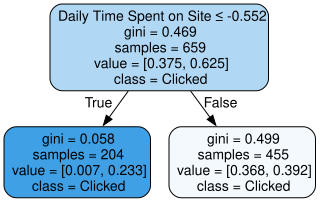

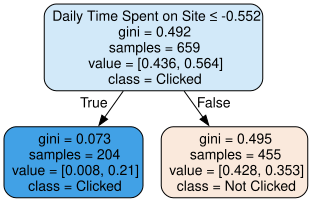

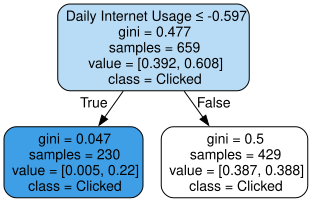

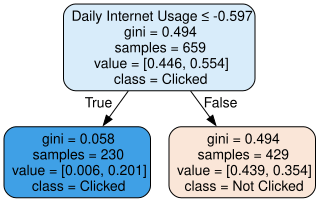

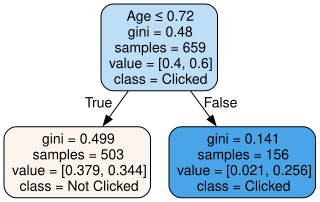

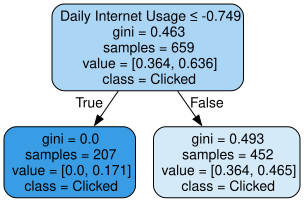

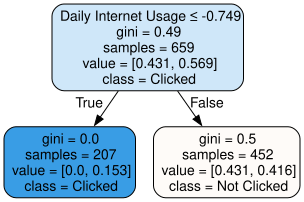

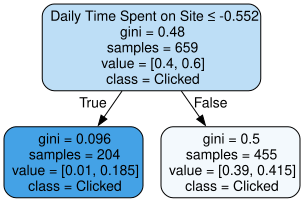

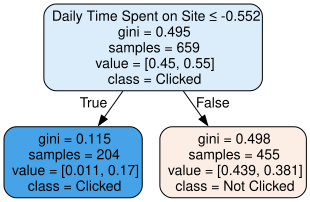

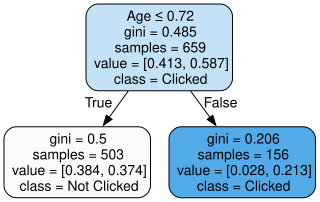

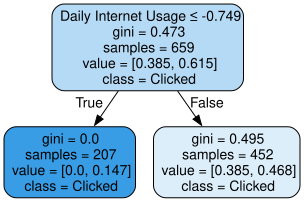

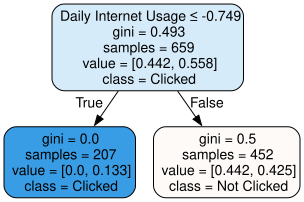

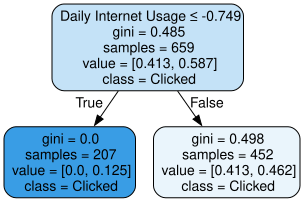

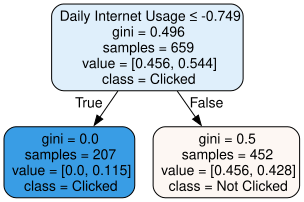

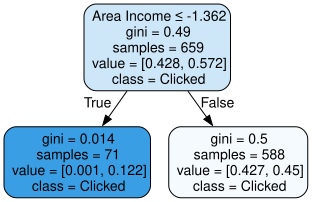

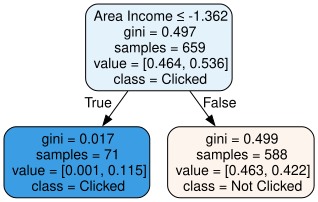

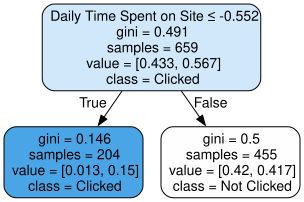

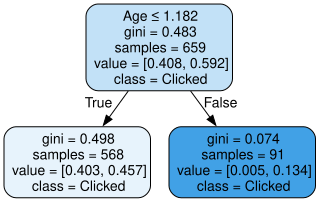

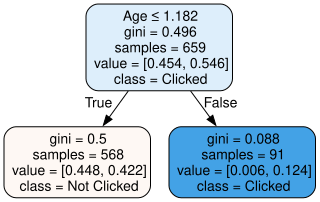

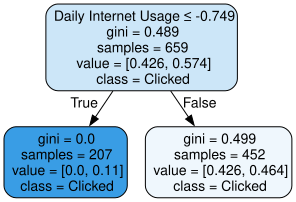

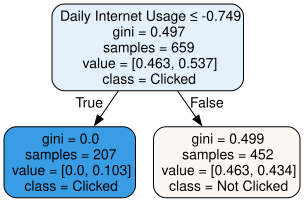

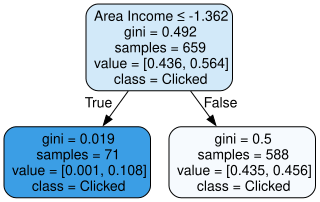

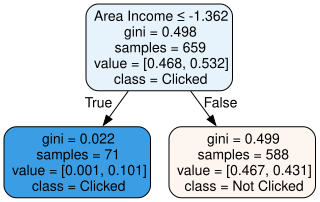

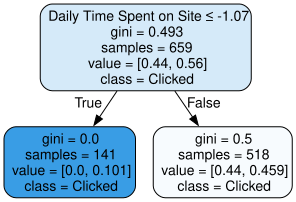

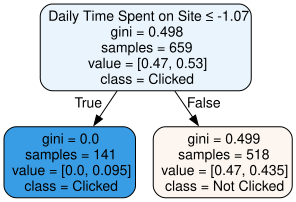

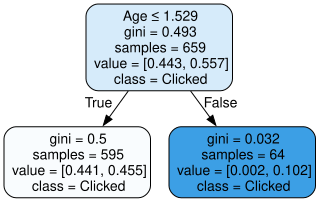

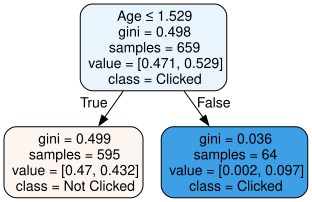

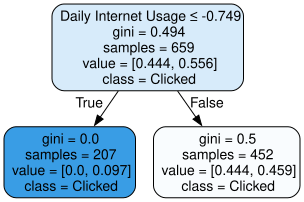

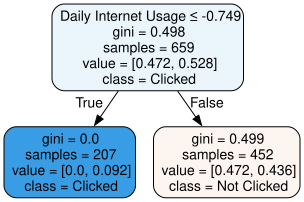

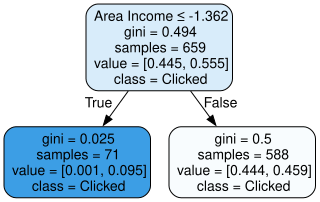

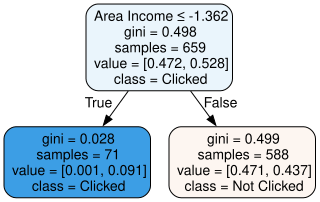

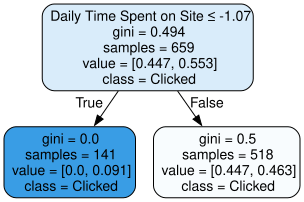

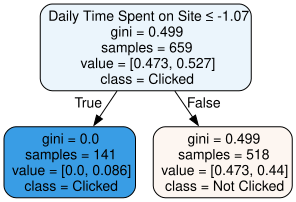

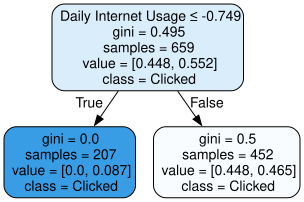

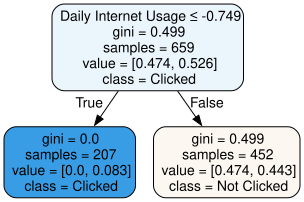

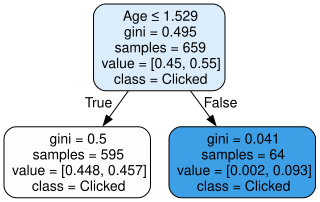

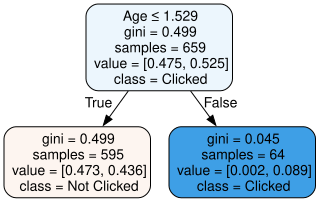

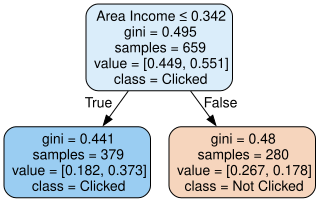

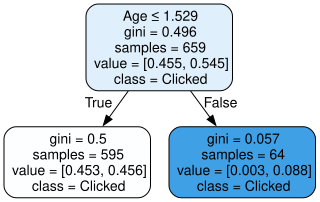

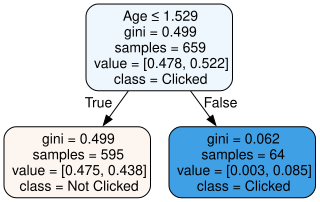

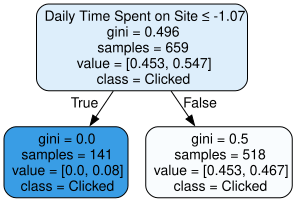

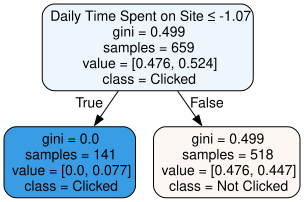

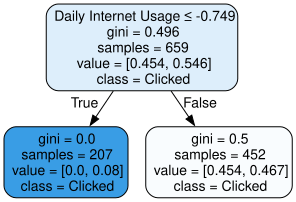

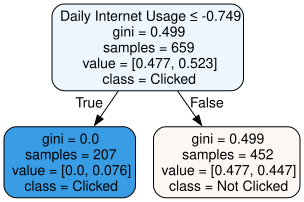

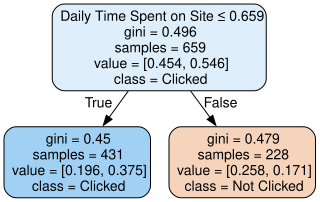

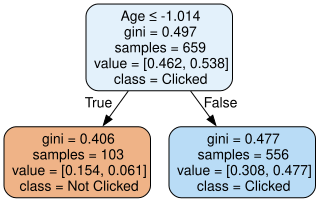

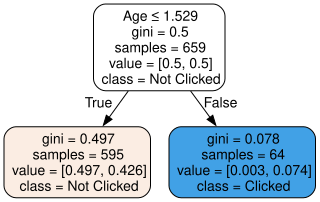

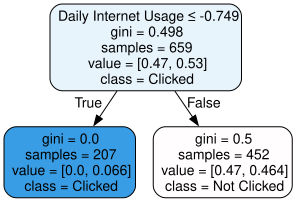

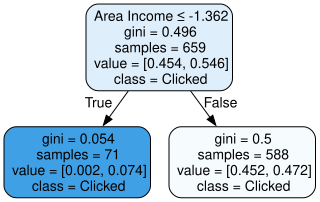

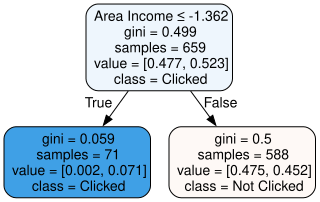

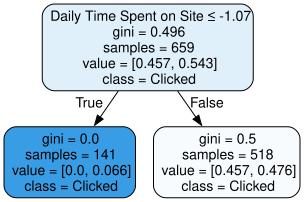

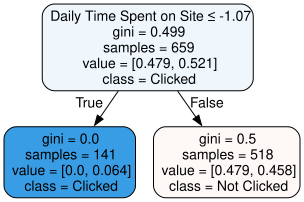

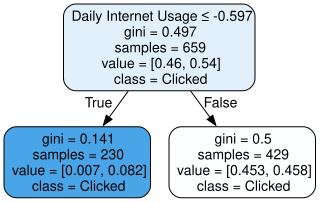

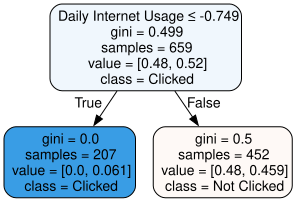

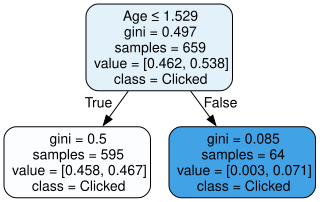

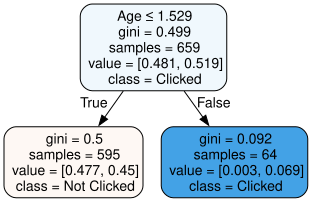

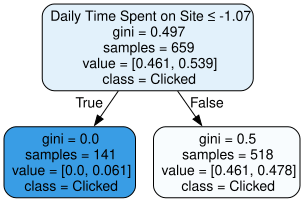

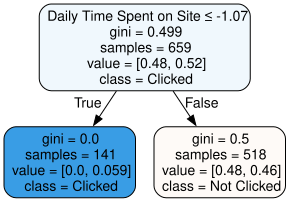

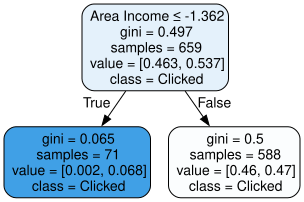

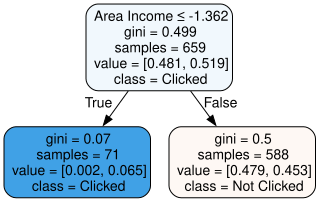

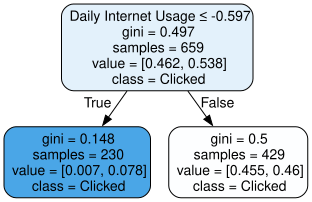

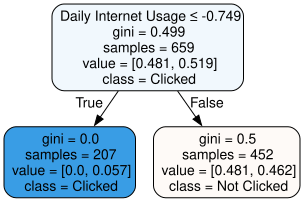

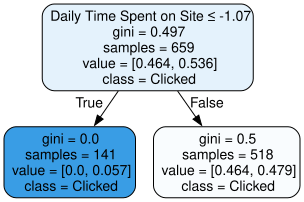

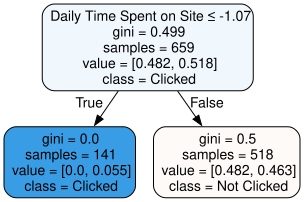

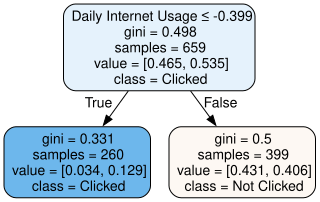

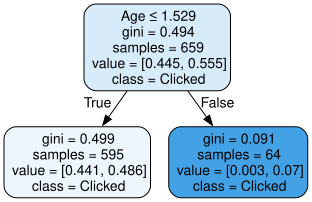

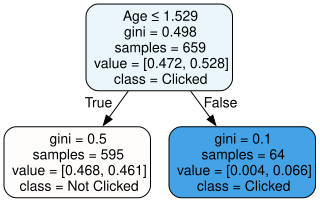

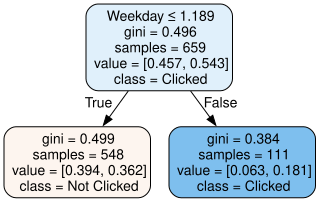

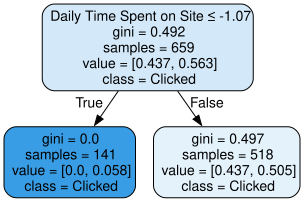

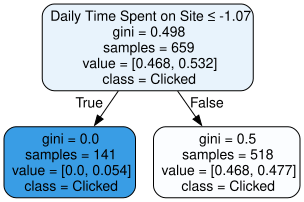

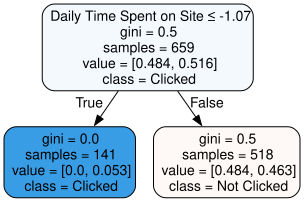

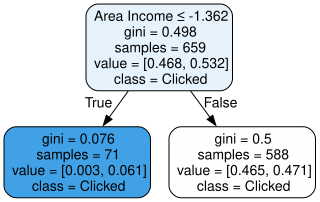

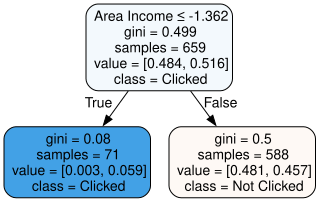

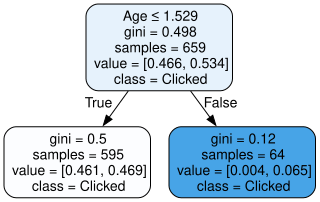

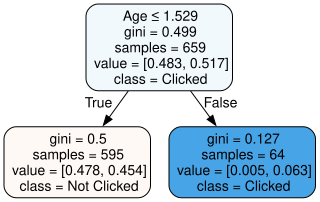

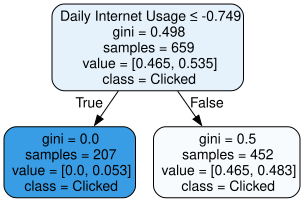

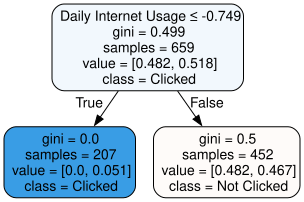

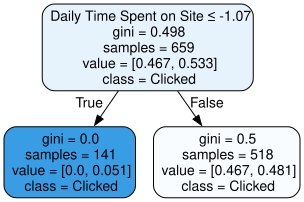

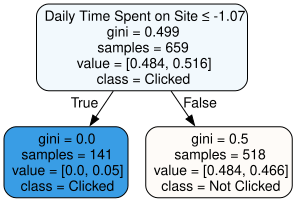

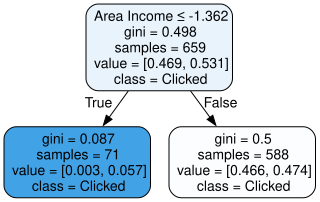

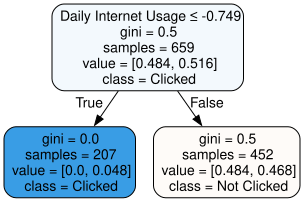

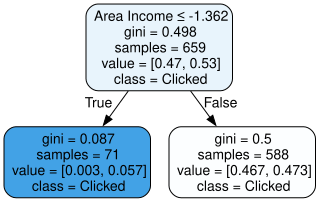

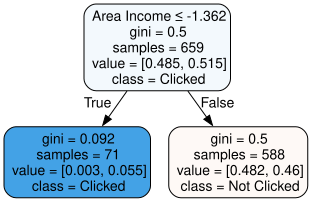

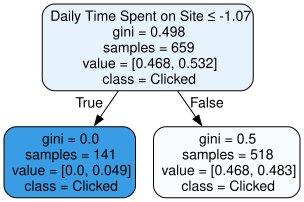

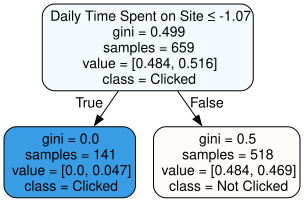

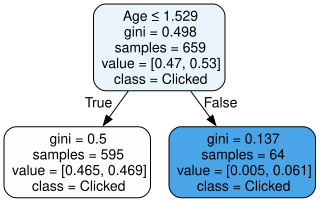

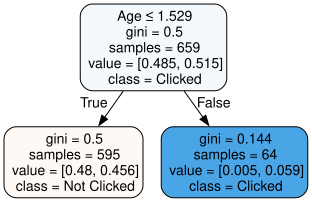

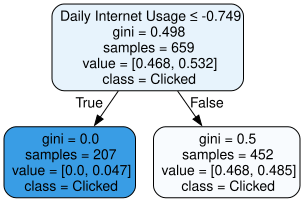

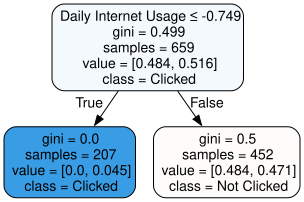

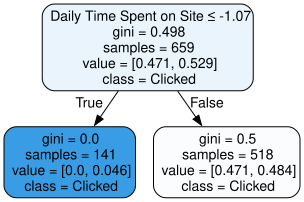

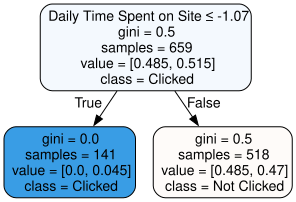

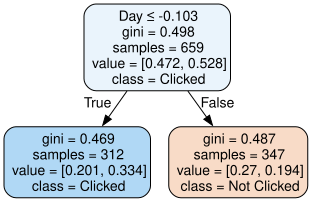

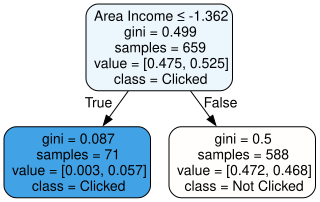

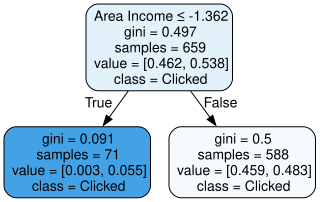

In [177]:
for i, tree in enumerate(clf.estimators_):
    dot_data = export_graphviz(
        tree,
        out_file=None,
        feature_names=feature_names,
        class_names=['Not Clicked', 'Clicked'],
        filled=True,
        rounded=True,
        special_characters=True
    )

    display(graphviz.Source(dot_data))

In [178]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,     
    max_depth=5,           
    random_state=42,      
    eval_metric='logloss' 
)

xgb_classifier.fit(X_train, y_train)


y_pred = xgb_classifier.predict(X_test)

cnf_matrix = confusion_matrix(y_test, y_pred)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       148
           1       0.95      0.98      0.96       138

    accuracy                           0.97       286
   macro avg       0.96      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



In [179]:
print(confusion_matrix(y_test, y_pred))

[[141   7]
 [  3 135]]


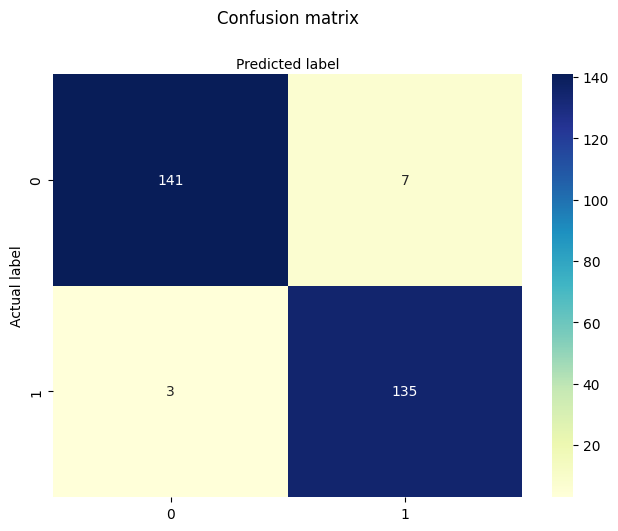

In [180]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [181]:
xgb_pred = xgb_classifier.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)  
print(f"Test Accuracy: {xgb_acc:.4f}")

Test Accuracy: 0.9650


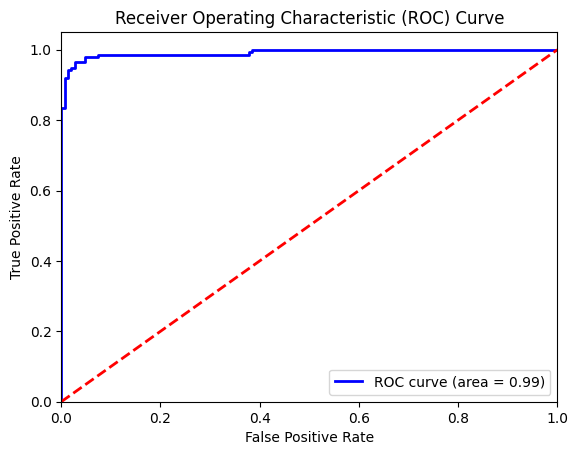

In [182]:
y_prob = xgb_classifier.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

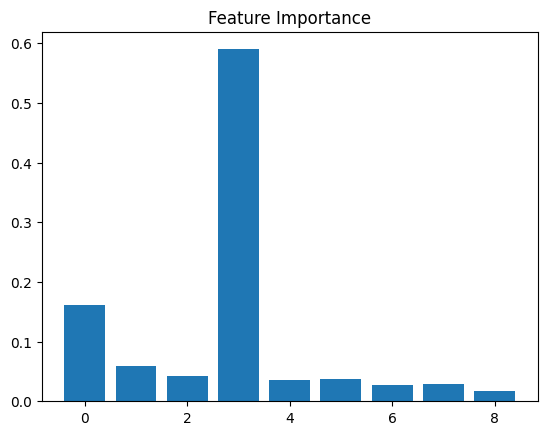

In [183]:
import matplotlib.pyplot as plt

importances = xgb_classifier.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()